<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Titanic_Data_Understanding_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Centric AI — Lab: Data Understanding on the Titanic dataset

**Course:** Data Centric AI — Module I (Prof. M. Golfarelli)
**Topic:** Business & Data Understanding (CRISP-DM, step 2)

In this exercise you will carry out the *Data Understanding* step of CRISP-DM on a classic tabular dataset. You will apply the tools introduced in the slides:

| Part | Content | Slides |
|---|---|---|
| 1 | Dataset description, attribute types | *Types of data, Attribute types* |
| 2 | Univariate analysis: statistical summary, distributions, outliers, skewness | *Univariate Analysis* |
| 3 | Bivariate analysis: visual inspection, pairplot, Pearson correlation, Mutual Information, dataset slicing | *Bivariate Analysis* |
| 4 | Multivariate analysis: explaining the data in a 2D latent space with PCA and t-SNE | *Multivariate Analysis* |

Throughout the notebook the **class attribute** (`Survived`) is always encoded with the same two colors, so that you can see how attribute values are distributed with respect to the class:

<span style="color:#D55E00">■ **0 = Died**</span> &nbsp;&nbsp; <span style="color:#0072B2">■ **1 = Survived**</span>

Cells marked with  contain questions: write your answers in the  cells that follow. Remember the advice from the slides: *the most effective way to verify the claims of domain experts is to check them against the data* — every answer should be supported by a number or a chart.

> **Note.** This is a *data understanding* exercise: we deliberately do **not** clean, impute or transform the data (that is the job of Data Preparation). When a technique requires complete data (PCA, t-SNE) we simply drop incomplete rows and discuss the consequences.

## 0. Setup

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

# One color per class value, used in EVERY chart of the notebook
CLASS = "Survived"
PALETTE = {0: "#D55E00", 1: "#0072B2"}          # 0 = Died, 1 = Survived
CLASS_LABELS = {0: "Died (0)", 1: "Survived (1)"}
RANDOM_STATE = 42

---
# Part 1 — The dataset and its attributes

## 1.1 Business understanding

On 15 April 1912 the RMS *Titanic* sank during her maiden voyage after colliding with an iceberg. There were not enough lifeboats for everyone on board and about 2/3 of passengers and crew died.

The dataset describes **891 passengers** (the "training" portion of the well-known Kaggle competition). The business question is:

> *Which kinds of people were more likely to survive?*

i.e., a **binary classification** problem whose class attribute is `Survived`. Before building any model, we want to understand the data, form hypotheses and check common beliefs (e.g. *"women and children first"*) against the data.

## 1.2 Loading the data

In [38]:
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
try:
    df = pd.read_csv(URL)
except Exception as e:
    # If the download fails, upload titanic.csv to the Colab session (folder icon on the left)
    df = pd.read_csv("titanic.csv")

print(f"Number of objects (rows):     {df.shape[0]}")
print(f"Number of attributes (cols):  {df.shape[1]}")

Number of objects (rows):     891
Number of attributes (cols):  12


## 1.3 Attribute description

| Attribute | Description | Values / unit |
|---|---|---|
| `PassengerId` | Unique identifier of the passenger | 1 … 891 |
| `Survived` | **Class attribute**: did the passenger survive? | 0 = No, 1 = Yes |
| `Pclass` | Ticket class, a proxy of socio-economic status | 1 = 1st (upper), 2 = 2nd (middle), 3 = 3rd (lower) |
| `Name` | Full name, including the title (Mr., Mrs., Miss., Master., …) | text |
| `Sex` | Sex of the passenger | male / female |
| `Age` | Age in years (fractional if < 1; `xx.5` if estimated) | years |
| `SibSp` | Number of siblings / spouses aboard | count |
| `Parch` | Number of parents / children aboard | count |
| `Ticket` | Ticket number | alphanumeric code |
| `Fare` | Passenger fare (a ticket may be shared by several passengers) | pre-1970 British pounds |
| `Cabin` | Cabin number (the first letter is the deck, A…G) | alphanumeric code |
| `Embarked` | Port of embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

## 1.4 Some example tuples

Here are 20 randomly selected objects. Look at them carefully: many questions below can be answered just by reading raw rows.

In [39]:
df.sample(20, random_state=RANDOM_STATE)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
333,334,0,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S
208,209,1,3,"Carr, Miss. Helen ""Ellen""",female,16.0,0,0,367231,7.7500,NaN,Q
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S


In [40]:
# Physical types assigned by pandas and number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [41]:
# Cardinality (number of distinct values) and missing values of each attribute
profile = pd.DataFrame({
    "pandas dtype": df.dtypes.astype(str),
    "distinct values": df.nunique(),
    "missing": df.isna().sum(),
    "missing %": (df.isna().mean() * 100).round(1),
    "example values": [df[c].dropna().unique()[:4].tolist() for c in df.columns],
})
profile

,pandas dtype,distinct values,missing,missing %,example values
PassengerId,int64,891,0,0.0,"[1, 2, 3, 4]"
Survived,int64,2,0,0.0,"[0, 1]"
Pclass,int64,3,0,0.0,"[3, 1, 2]"
Name,object,891,0,0.0,"[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
Sex,object,2,0,0.0,"[male, female]"
Age,float64,88,177,19.9,"[22.0, 38.0, 26.0, 35.0]"
SibSp,int64,7,0,0.0,"[1, 0, 3, 4]"
Parch,int64,7,0,0.0,"[0, 1, 2, 5]"
Ticket,object,681,0,0.0,"[A/5 21171, PC 17599, STON/O2. 3101282, 113803]"
Fare,float64,248,0,0.0,"[7.25, 71.2833, 7.925, 53.1]"


###  Questions — attribute types

Recall the taxonomy in the slides: **nominal**, **ordinal** (categorical/qualitative) and **interval**, **ratio** (numerical/quantitative); and the alternative classification **binary / discrete / continuous**, plus **asymmetric** attributes.

1. Fill in the following table, assigning to each attribute its type (nominal / ordinal / interval / ratio) and whether it is binary, discrete or continuous. Justify the less obvious choices referring to the *operators that make sense* on the values (=, <, +, ×).

   | Attribute | Nominal / Ordinal / Interval / Ratio | Binary / Discrete / Continuous |
   |---|---|---|
   | PassengerId | | |
   | Survived | | |
   | Pclass | | |
   | Name | | |
   | Sex | | |
   | Age | | |
   | SibSp | | |
   | Parch | | |
   | Ticket | | |
   | Fare | | |
   | Cabin | | |
   | Embarked | | |

2. `PassengerId`, `Survived` and `Pclass` are stored by pandas as integers (`int64`). Does it make sense to compute the **mean** of each of them? For which one is the mean meaningful *although* it is not a quantitative attribute? (Hint: what does the mean of a 0/1 attribute represent?)
3. `Pclass` is coded 1, 2, 3. Is the difference between 1st and 2nd class "the same" as the difference between 2nd and 3rd? Which statistical operators of the slides are therefore admissible on `Pclass`?
4. `Age` is a ratio attribute, while *year of birth* would be an interval attribute. Explain why, using the Celsius vs Kelvin example of the slides.
5. `SibSp` and `Parch` are counts. Are they discrete or continuous? Is the set of their possible values finite or *countably infinite*?
6. Which attributes have a **high cardinality** (many distinct values compared to the number of rows)? Are they useful "as is" for a classifier? Can you see any *hidden* information in them, looking at the 20 example tuples? (Look at `Name`, `Cabin`, `Ticket`.)
7. Which attributes have **missing values**? For `Cabin`, is the missing value a "data quality error" or could the fact that it is missing be *informative* by itself?
8. What is the **granularity** of the data (see *Additional Profiling Information*)? Does each row represent a passenger, a ticket or a family? Is the crew included?

>  **Your answers:**
>
> ...

---
# Part 2 — Univariate analysis

Univariate analysis examines **one variable at a time**: its distribution, central tendency, spread and possible anomalies. Since we are in a classification setting, for each attribute we also look at how its values are distributed **with respect to the class** (colors).

## 2.1 The class attribute

The first attribute to study is the class itself: is the dataset **balanced**?

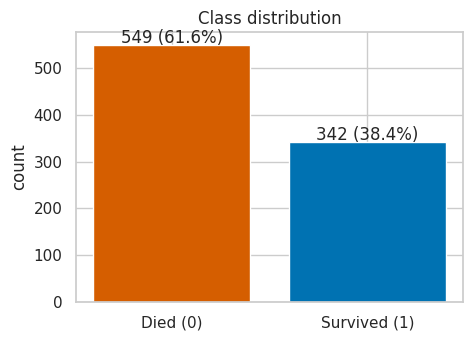

In [42]:
counts = df[CLASS].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar([CLASS_LABELS[k] for k in counts.index], counts.values,
              color=[PALETTE[k] for k in counts.index])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 5, f"{v} ({v/len(df):.1%})", ha="center")
ax.set_title("Class distribution"); ax.set_ylabel("count")
plt.show()

## 2.2 Categorical attributes: statistical summary

For categorical attributes the slides suggest: **frequency counts, relative frequencies, mode, cardinality, missing values**.

In [43]:
def categorical_summary(s: pd.Series, top=10) -> None:
    vc = s.value_counts(dropna=False)
    out = pd.DataFrame({"count": vc, "relative freq.": (vc / len(s)).round(3)})
    print(f"=== {s.name} ===")
    print(f"cardinality: {s.nunique()}  |  mode: {s.mode().iloc[0]!r}  |  "
          f"missing: {s.isna().sum()} ({s.isna().mean():.1%})")
    display(out.head(top))

for col in ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]:
    categorical_summary(df[col])

=== Pclass ===
cardinality: 3  |  mode: np.int64(3)  |  missing: 0 (0.0%)


,count,relative freq.
Pclass,,
3,491,0.551
1,216,0.242
2,184,0.207


=== Sex ===
cardinality: 2  |  mode: 'male'  |  missing: 0 (0.0%)


,count,relative freq.
Sex,,
male,577,0.648
female,314,0.352


=== Embarked ===
cardinality: 3  |  mode: 'S'  |  missing: 2 (0.2%)


,count,relative freq.
Embarked,,
S,644,0.723
C,168,0.189
Q,77,0.086
NaN,2,0.002


=== SibSp ===
cardinality: 7  |  mode: np.int64(0)  |  missing: 0 (0.0%)


,count,relative freq.
SibSp,,
0,608,0.682
1,209,0.235
2,28,0.031
4,18,0.020
3,16,0.018
8,7,0.008
5,5,0.006


=== Parch ===
cardinality: 7  |  mode: np.int64(0)  |  missing: 0 (0.0%)


,count,relative freq.
Parch,,
0,678,0.761
1,118,0.132
2,80,0.090
5,5,0.006
3,5,0.006
4,4,0.004
6,1,0.001


In [44]:
# High-cardinality attributes: only the most frequent values
for col in ["Ticket", "Cabin"]:
    categorical_summary(df[col], top=6)

=== Ticket ===
cardinality: 681  |  mode: '1601'  |  missing: 0 (0.0%)


,count,relative freq.
Ticket,,
347082,7,0.008
1601,7,0.008
CA. 2343,7,0.008
3101295,6,0.007
CA 2144,6,0.007
347088,6,0.007


=== Cabin ===
cardinality: 147  |  mode: 'B96 B98'  |  missing: 687 (77.1%)


,count,relative freq.
Cabin,,
NaN,687,0.771
G6,4,0.004
C23 C25 C27,4,0.004
B96 B98,4,0.004
F2,3,0.003
D,3,0.003


### Distribution with respect to the class

For each categorical/discrete attribute we draw two bar charts:
* **left** – absolute counts, stacked by class → shows how many objects take each value;
* **right** – proportions within each value (each bar sums to 1) → shows the *survival rate* for each value. The dashed line marks the overall died/survived split of the whole dataset: a value whose blue/orange boundary is far from the line is informative about the class.

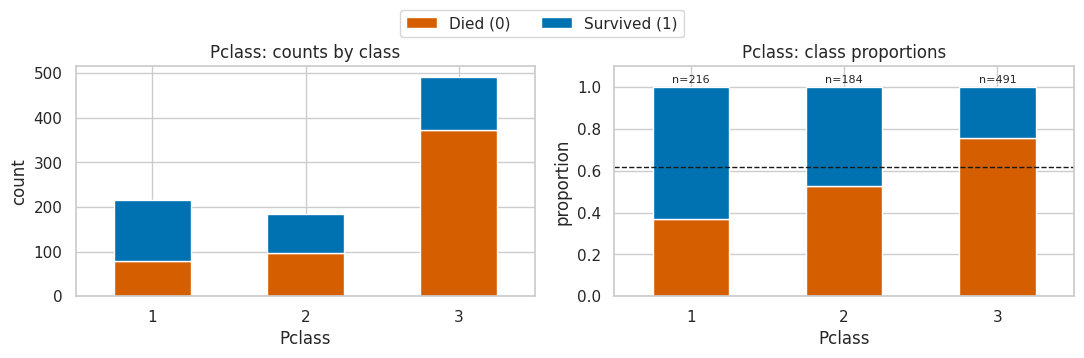

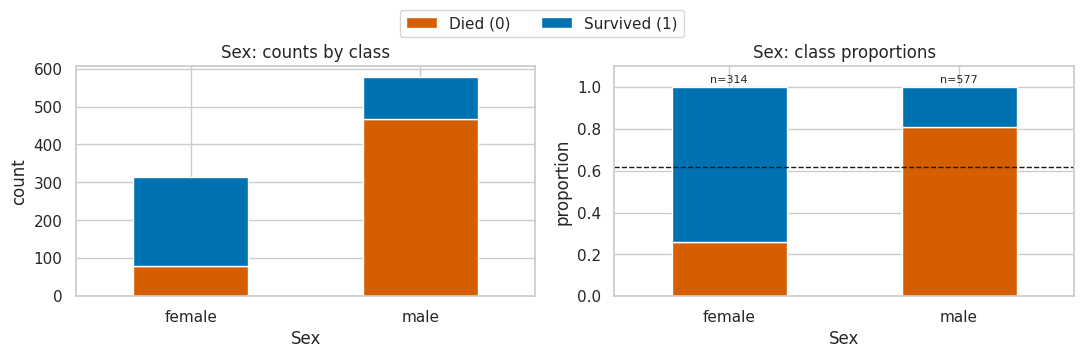

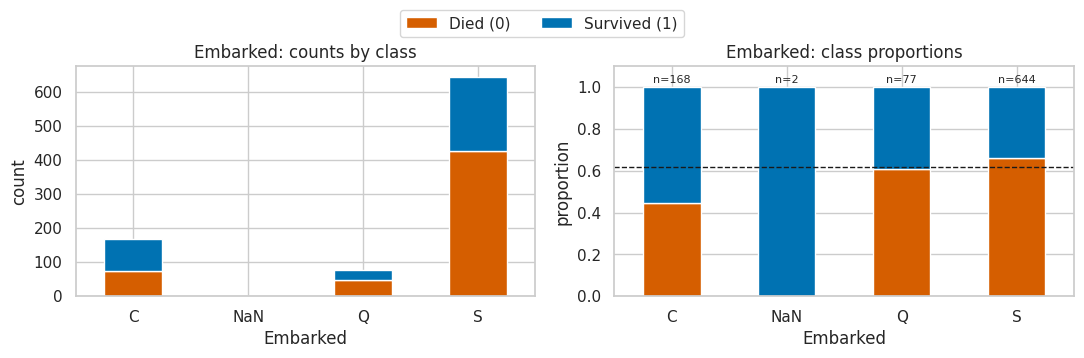

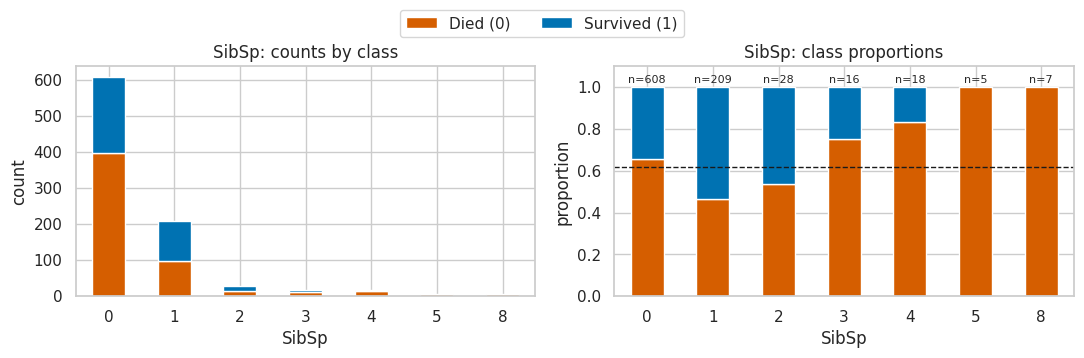

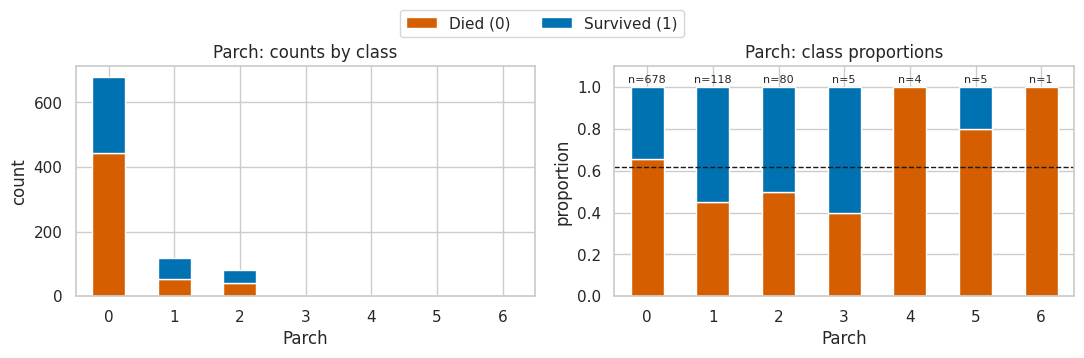

In [45]:
overall_rate = df[CLASS].mean()

def class_bars(col, data=df):
    ct = pd.crosstab(data[col].fillna("NaN"), data[CLASS])
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    ct.plot(kind="bar", stacked=True, ax=axes[0], color=[PALETTE[0], PALETTE[1]], rot=0, legend=False)
    axes[0].set_title(f"{col}: counts by class"); axes[0].set_ylabel("count")
    prop = ct.div(ct.sum(axis=1), axis=0)
    prop.plot(kind="bar", stacked=True, ax=axes[1], color=[PALETTE[0], PALETTE[1]], rot=0, legend=False)
    axes[1].axhline(1 - overall_rate, ls="--", color="k", lw=1)
    axes[1].set_title(f"{col}: class proportions"); axes[1].set_ylabel("proportion")
    for i, n in enumerate(ct.sum(axis=1)):
        axes[1].text(i, 1.02, f"n={n}", ha="center", fontsize=8)
    axes[1].set_ylim(0, 1.1)
    fig.legend([CLASS_LABELS[0], CLASS_LABELS[1]], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.07))
    plt.tight_layout(); plt.show()

for col in ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]:
    class_bars(col)

## 2.3 Numerical attributes: statistical summary

For numerical attributes the slides suggest measures of **central tendency** (mean, median, mode), **dispersion** (std, variance, range, IQR, AAD, MAD), **shape** (skewness, kurtosis), **position** (min/max, quartiles, percentiles) and **missing values**.

* AAD = *Absolute Average Deviation* = mean(|x − mean(x)|)
* MAD = *Median Absolute Deviation* = median(|x − median(x)|)
* pandas returns the *excess* kurtosis (0 for a normal distribution)

In [46]:
def numerical_summary(s: pd.Series) -> pd.Series:
    x = s.dropna()
    q1, q2, q3 = x.quantile([.25, .5, .75])
    return pd.Series({
        "count": x.size, "missing": s.isna().sum(), "missing %": round(100 * s.isna().mean(), 1),
        "mean": x.mean(), "median": q2, "mode": x.mode().iloc[0],
        "std": x.std(), "variance": x.var(), "min": x.min(), "max": x.max(),
        "range": x.max() - x.min(), "Q1": q1, "Q3": q3, "IQR": q3 - q1,
        "P5": x.quantile(.05), "P95": x.quantile(.95),
        "AAD": (x - x.mean()).abs().mean(), "MAD": (x - q2).abs().median(),
        "skewness": x.skew(), "kurtosis (excess)": x.kurt(),
    })

num_cols = ["Age", "Fare", "SibSp", "Parch"]
summary = pd.DataFrame({c: numerical_summary(df[c]) for c in num_cols}).round(3)
summary

,Age,Fare,SibSp,Parch
count,714.000,891.000,891.000,891.000
missing,177.000,0.000,0.000,0.000
missing %,19.900,0.000,0.000,0.000
mean,29.699,32.204,0.523,0.382
median,28.000,14.454,0.000,0.000
mode,24.000,8.050,0.000,0.000
std,14.526,49.693,1.103,0.806
variance,211.019,2469.437,1.216,0.650
min,0.420,0.000,0.000,0.000
max,80.000,512.329,8.000,6.000


In [47]:
# The same summary, computed separately for each class (dataset slicing on the class attribute)
for c in ["Age", "Fare"]:
    print(f"=== {c} by class ===")
    display(pd.DataFrame({CLASS_LABELS[k]: numerical_summary(g[c]) for k, g in df.groupby(CLASS)}).round(2).T
            [["count", "missing %", "mean", "median", "std", "IQR", "skewness"]])

=== Age by class ===


,count,missing %,mean,median,std,IQR,skewness
Died (0),424.0,22.8,30.63,28.0,14.17,18.0,0.59
Survived (1),290.0,15.2,28.34,28.0,14.95,17.0,0.18


=== Fare by class ===


,count,missing %,mean,median,std,IQR,skewness
Died (0),549.0,0.0,22.12,10.5,31.39,18.15,4.55
Survived (1),342.0,0.0,48.40,26.0,66.60,44.52,3.86


## 2.4 Distributions: histograms, density plots and box plots

For `Age` and `Fare` we draw:
1. a histogram **stacked by class**, with mean (solid) and median (dashed) lines;
2. the **density** of each class, normalised separately (so that the two shapes can be compared regardless of class size);
3. **box plots** per class (whiskers at 1.5·IQR; points beyond the whiskers are *candidate* outliers).

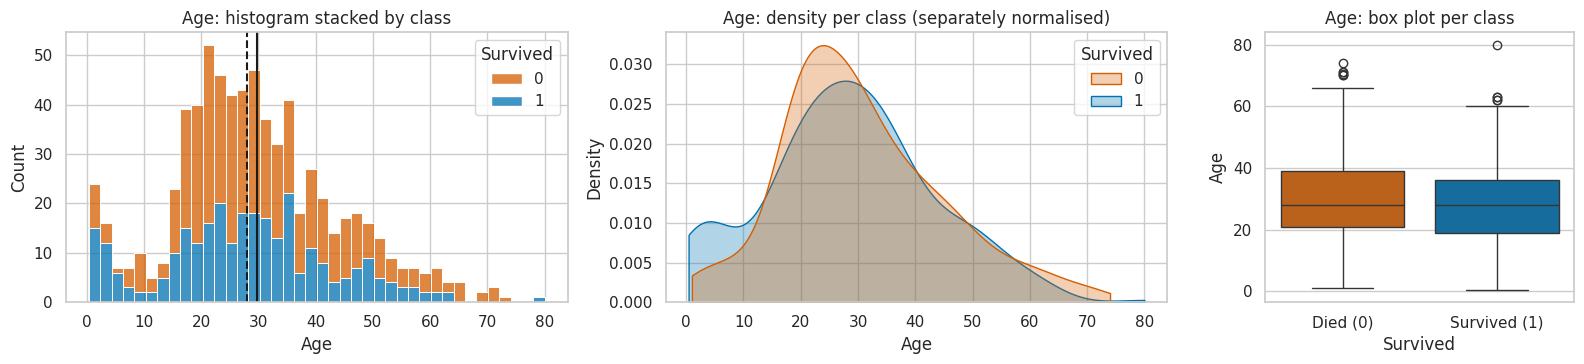

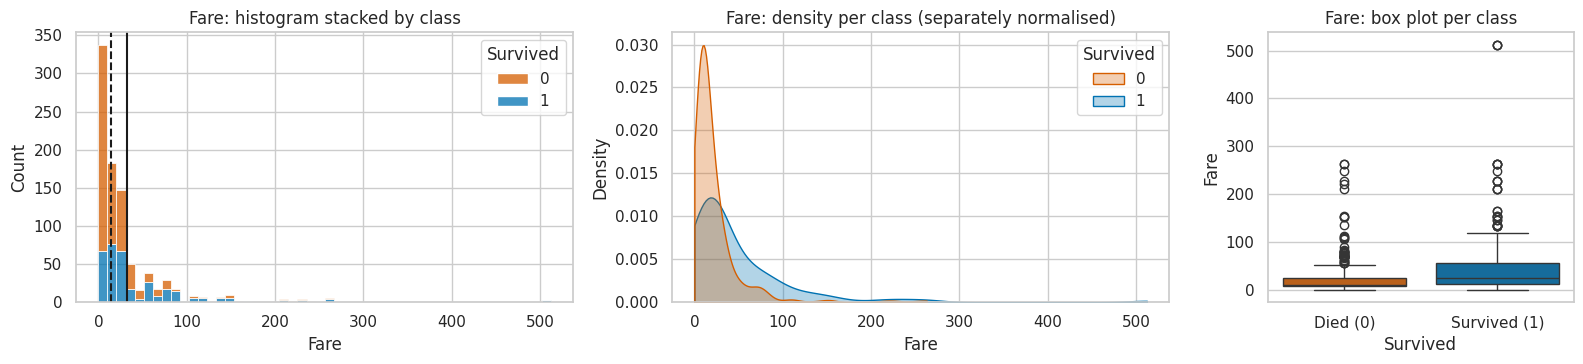

In [48]:
def univariate_plots(col, bins=40, log=False):
    data = df[[col, CLASS]].dropna()
    fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), gridspec_kw={"width_ratios": [1.3, 1.3, 0.8]})
    sns.histplot(data=data, x=col, hue=CLASS, palette=PALETTE, multiple="stack", bins=bins,
                 ax=axes[0], log_scale=log)
    axes[0].axvline(data[col].mean(), color="k", lw=1.5, label="mean")
    axes[0].axvline(data[col].median(), color="k", lw=1.5, ls="--", label="median")
    axes[0].set_title(f"{col}: histogram stacked by class")
    sns.kdeplot(data=data, x=col, hue=CLASS, palette=PALETTE, common_norm=False, fill=True,
                alpha=.3, ax=axes[1], log_scale=log, cut=0)
    axes[1].set_title(f"{col}: density per class (separately normalised)")
    sns.boxplot(data=data, x=CLASS, y=col, hue=CLASS, palette=PALETTE, ax=axes[2], legend=False,
                log_scale=log)
    axes[2].set_xticks([0, 1], [CLASS_LABELS[0], CLASS_LABELS[1]])
    axes[2].set_title(f"{col}: box plot per class")
    plt.tight_layout(); plt.show()

univariate_plots("Age", bins=40)
univariate_plots("Fare", bins=50)

## 2.5 Outliers

A simple univariate rule (Tukey's rule, used by box plots) labels as *candidate outliers* the values outside

$$[\,Q_1 - 1.5\cdot IQR,\; Q_3 + 1.5\cdot IQR\,]$$

Remember: an outlier is not necessarily an *error*. It can be a rare but correct value (and possibly the most interesting one!). Outlier detection will be studied in depth in a later module.

In [49]:
def iqr_outliers(s: pd.Series, k=1.5):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return lo, hi, (s < lo) | (s > hi)

rows = []
for c in num_cols:
    lo, hi, mask = iqr_outliers(df[c].dropna())
    out = df.loc[mask[mask].index]
    rows.append({"attribute": c, "lower fence": round(lo, 2), "upper fence": round(hi, 2),
                 "# outliers": int(mask.sum()), "% outliers": round(100 * mask.mean(), 1),
                 "survival rate among outliers": round(out[CLASS].mean(), 2)})
pd.DataFrame(rows)

,attribute,lower fence,upper fence,# outliers,% outliers,survival rate among outliers
0,Age,-6.69,64.81,11,1.5,0.09
1,Fare,-26.72,65.63,116,13.0,0.68
2,SibSp,-1.50,2.50,46,5.2,0.15
3,Parch,0.00,0.00,213,23.9,0.51


In [50]:
# The most extreme fares
df.sort_values("Fare", ascending=False).head(8)[["PassengerId", "Survived", "Pclass", "Name", "Age", "Fare", "Ticket", "Cabin"]]

,PassengerId,Survived,Pclass,Name,Age,Fare,Ticket,Cabin
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",36.0,512.3292,PC 17755,B51 B53 B55
258,259,1,1,"Ward, Miss. Anna",35.0,512.3292,PC 17755,NaN
737,738,1,1,"Lesurer, Mr. Gustave J",35.0,512.3292,PC 17755,B101
88,89,1,1,"Fortune, Miss. Mabel Helen",23.0,263.0000,19950,C23 C25 C27
438,439,0,1,"Fortune, Mr. Mark",64.0,263.0000,19950,C23 C25 C27
341,342,1,1,"Fortune, Miss. Alice Elizabeth",24.0,263.0000,19950,C23 C25 C27
27,28,0,1,"Fortune, Mr. Charles Alexander",19.0,263.0000,19950,C23 C25 C27
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",21.0,262.3750,PC 17608,B57 B59 B63 B66


In [51]:
# ... and at the other end: passengers who paid nothing
zero_fare = df[df["Fare"] == 0]
print(f"{len(zero_fare)} passengers with Fare = 0")
zero_fare[["PassengerId", "Survived", "Pclass", "Name", "Age", "SibSp", "Parch", "Ticket", "Fare", "Embarked"]]

15 passengers with Fare = 0


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Embarked
179,180,0,3,"Leonard, Mr. Lionel",36.0,0,0,LINE,0.0,S
263,264,0,1,"Harrison, Mr. William",40.0,0,0,112059,0.0,S
271,272,1,3,"Tornquist, Mr. William Henry",25.0,0,0,LINE,0.0,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",NaN,0,0,239853,0.0,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",19.0,0,0,LINE,0.0,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",NaN,0,0,239853,0.0,S
466,467,0,2,"Campbell, Mr. William",NaN,0,0,239853,0.0,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",NaN,0,0,239854,0.0,S
597,598,0,3,"Johnson, Mr. Alfred",49.0,0,0,LINE,0.0,S
633,634,0,1,"Parr, Mr. William Henry Marsh",NaN,0,0,112052,0.0,S


In [52]:
# Is a high Fare per passenger or per ticket? Passengers sharing the same ticket
shared = df.groupby("Ticket").agg(n_passengers=("PassengerId", "size"), fare=("Fare", "first"),
                                   n_distinct_fares=("Fare", "nunique")).sort_values("n_passengers", ascending=False)
shared.head(8)

,n_passengers,fare,n_distinct_fares
Ticket,,,
1601,7,56.4958,1
CA. 2343,7,69.5500,1
347082,7,31.2750,1
CA 2144,6,46.9000,1
3101295,6,39.6875,1
347088,6,27.9000,1
382652,5,29.1250,1
S.O.C. 14879,5,73.5000,1


## 2.6 Skewness

`Fare` is strongly right-skewed (long tail of expensive tickets), while `Age` is only mildly skewed. A common way to reduce right skewness is the logarithmic transformation; we use `log(1 + x)` because some fares are 0. *(Here we only look at it: applying transformations is part of Data Preparation / Feature Engineering.)*

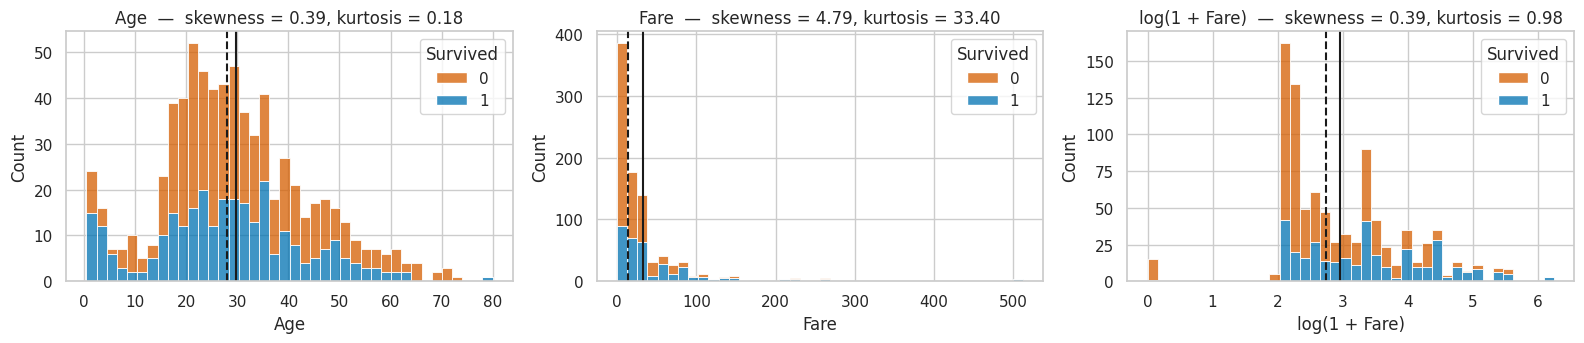

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
for ax, (lbl, s) in zip(axes, [("Age", df["Age"]), ("Fare", df["Fare"]), ("log(1 + Fare)", np.log1p(df["Fare"]))]):
    d = pd.DataFrame({lbl: s, CLASS: df[CLASS]}).dropna()
    sns.histplot(data=d, x=lbl, hue=CLASS, palette=PALETTE, multiple="stack", bins=40, ax=ax, kde=False)
    ax.axvline(d[lbl].mean(), color="k", lw=1.5); ax.axvline(d[lbl].median(), color="k", ls="--", lw=1.5)
    ax.set_title(f"{lbl}  —  skewness = {d[lbl].skew():.2f}, kurtosis = {d[lbl].kurt():.2f}")
plt.tight_layout(); plt.show()

###  Questions — univariate analysis

**Class and categorical attributes**
1. Is the dataset balanced with respect to the class? What would be the accuracy of a trivial classifier that always predicts the mode?
2. For `Pclass`, `Sex` and `Embarked`: which values have a survival rate far from the overall one? Does the data confirm the *"women first"* claim?
3. The proportion charts of `SibSp` and `Parch` show very different survival rates for large values. Look at the `n=` labels above the bars: how much would you trust those rates? Why is it important to look at counts and proportions together?
4. `Embarked` has 2 missing values and `Cabin` 687. Why can these two cases not be treated in the same way?

**Numerical attributes**

5. Compare mean and median of `Age` and `Fare`. Which one is more affected by the tail of the distribution? Which central tendency measure would you report for `Fare` and why?
6. Compare `std` with `AAD` and `MAD` for `Fare`. Why are these measures so different? Which ones are *robust* to outliers?
7. The mode of `Age` is a "round" number and the histogram shows peaks on multiples of 5 and values like `xx.5`. What does this tell you about the **data collection process** (measurement errors / estimated values)?
8. Look at the density of `Age` per class: in which age range is the "Survived" density clearly above the "Died" one? Formulate a hypothesis.

**Outliers and skewness**

9. How many candidate outliers does Tukey's rule find for `Fare`? Are they errors or correct values? Look at the passengers who paid 512.33 and at the shared tickets: what does `Fare` actually measure (price per person or per ticket)? What is the consequence for the analysis?
10. 15 passengers have `Fare = 0`. Are they plausible? What kind of passengers could they be (look at their `Pclass`, `Ticket`, age and sex)? Would you treat them as missing values?
11. Tukey's rule labels as outliers *all* passengers with `Parch > 0`. Is the rule appropriate for this attribute? Why does it fail? (Hint: look at Q1, Q3 and the IQR.)
12. Is the skewness of `Fare` positive or negative? Explain how you could have predicted its sign from the relative position of mean and median, and verify it on the histograms. How does the log transformation change skewness and kurtosis?
13. Is the survival rate of the `Fare` outliers higher or lower than the overall one? Would removing them be a good idea for a model that predicts survival?

>  **Your answers:**
>
> ...

---
# Part 3 — Bivariate analysis

Bivariate analysis studies the **relationship between two variables**, to reveal dependencies, correlations or patterns. As in the slides, we will use:
* **visual inspection**, choosing the chart according to the attribute types;
* **Pearson correlation** for *linear* relationships;
* **Mutual Information** for *any* (also non-linear) dependency.

## 3.1 Numerical encoding of the attributes

Pairplots, correlation and (later) PCA need numbers. We build a working table `X` with:
* `Sex_female`: 1 = female, 0 = male (binary);
* `Embarked_code`: C = 0, Q = 1, S = 2 ( an *arbitrary* coding of a nominal attribute — keep it in mind when reading the correlations);
* the high-cardinality identifiers (`PassengerId`, `Name`, `Ticket`, `Cabin`) are excluded.

In [54]:
X = pd.DataFrame({
    "Pclass": df["Pclass"],
    "Sex_female": (df["Sex"] == "female").astype(int),
    "Age": df["Age"],
    "SibSp": df["SibSp"],
    "Parch": df["Parch"],
    "Fare": df["Fare"],
    "Embarked_code": df["Embarked"].map({"C": 0, "Q": 1, "S": 2}),
    CLASS: df[CLASS],
})
features = [c for c in X.columns if c != CLASS]
X.head()

,Pclass,Sex_female,Age,SibSp,Parch,Fare,Embarked_code,Survived
0,3,0,22.0,1,0,7.2500,2.0,0
1,1,1,38.0,1,0,71.2833,0.0,1
2,3,1,26.0,0,0,7.9250,2.0,1
3,1,1,35.0,1,0,53.1000,2.0,1
4,3,0,35.0,0,0,8.0500,2.0,0


## 3.2 Pairplot of all the attributes

A **pairplot** shows the scatter plot of each pair of attributes (off-diagonal) and the distribution of each attribute per class (diagonal).

Many attributes are discrete (`Pclass`, `Sex_female`, `SibSp`, `Parch`, `Embarked_code`): in a plain scatter plot hundreds of points would be drawn exactly on top of each other (*over-plotting*). To make the density visible we add a small random **jitter** to the discrete attributes, **only for plotting** — set `JITTER = False` to see the raw version.

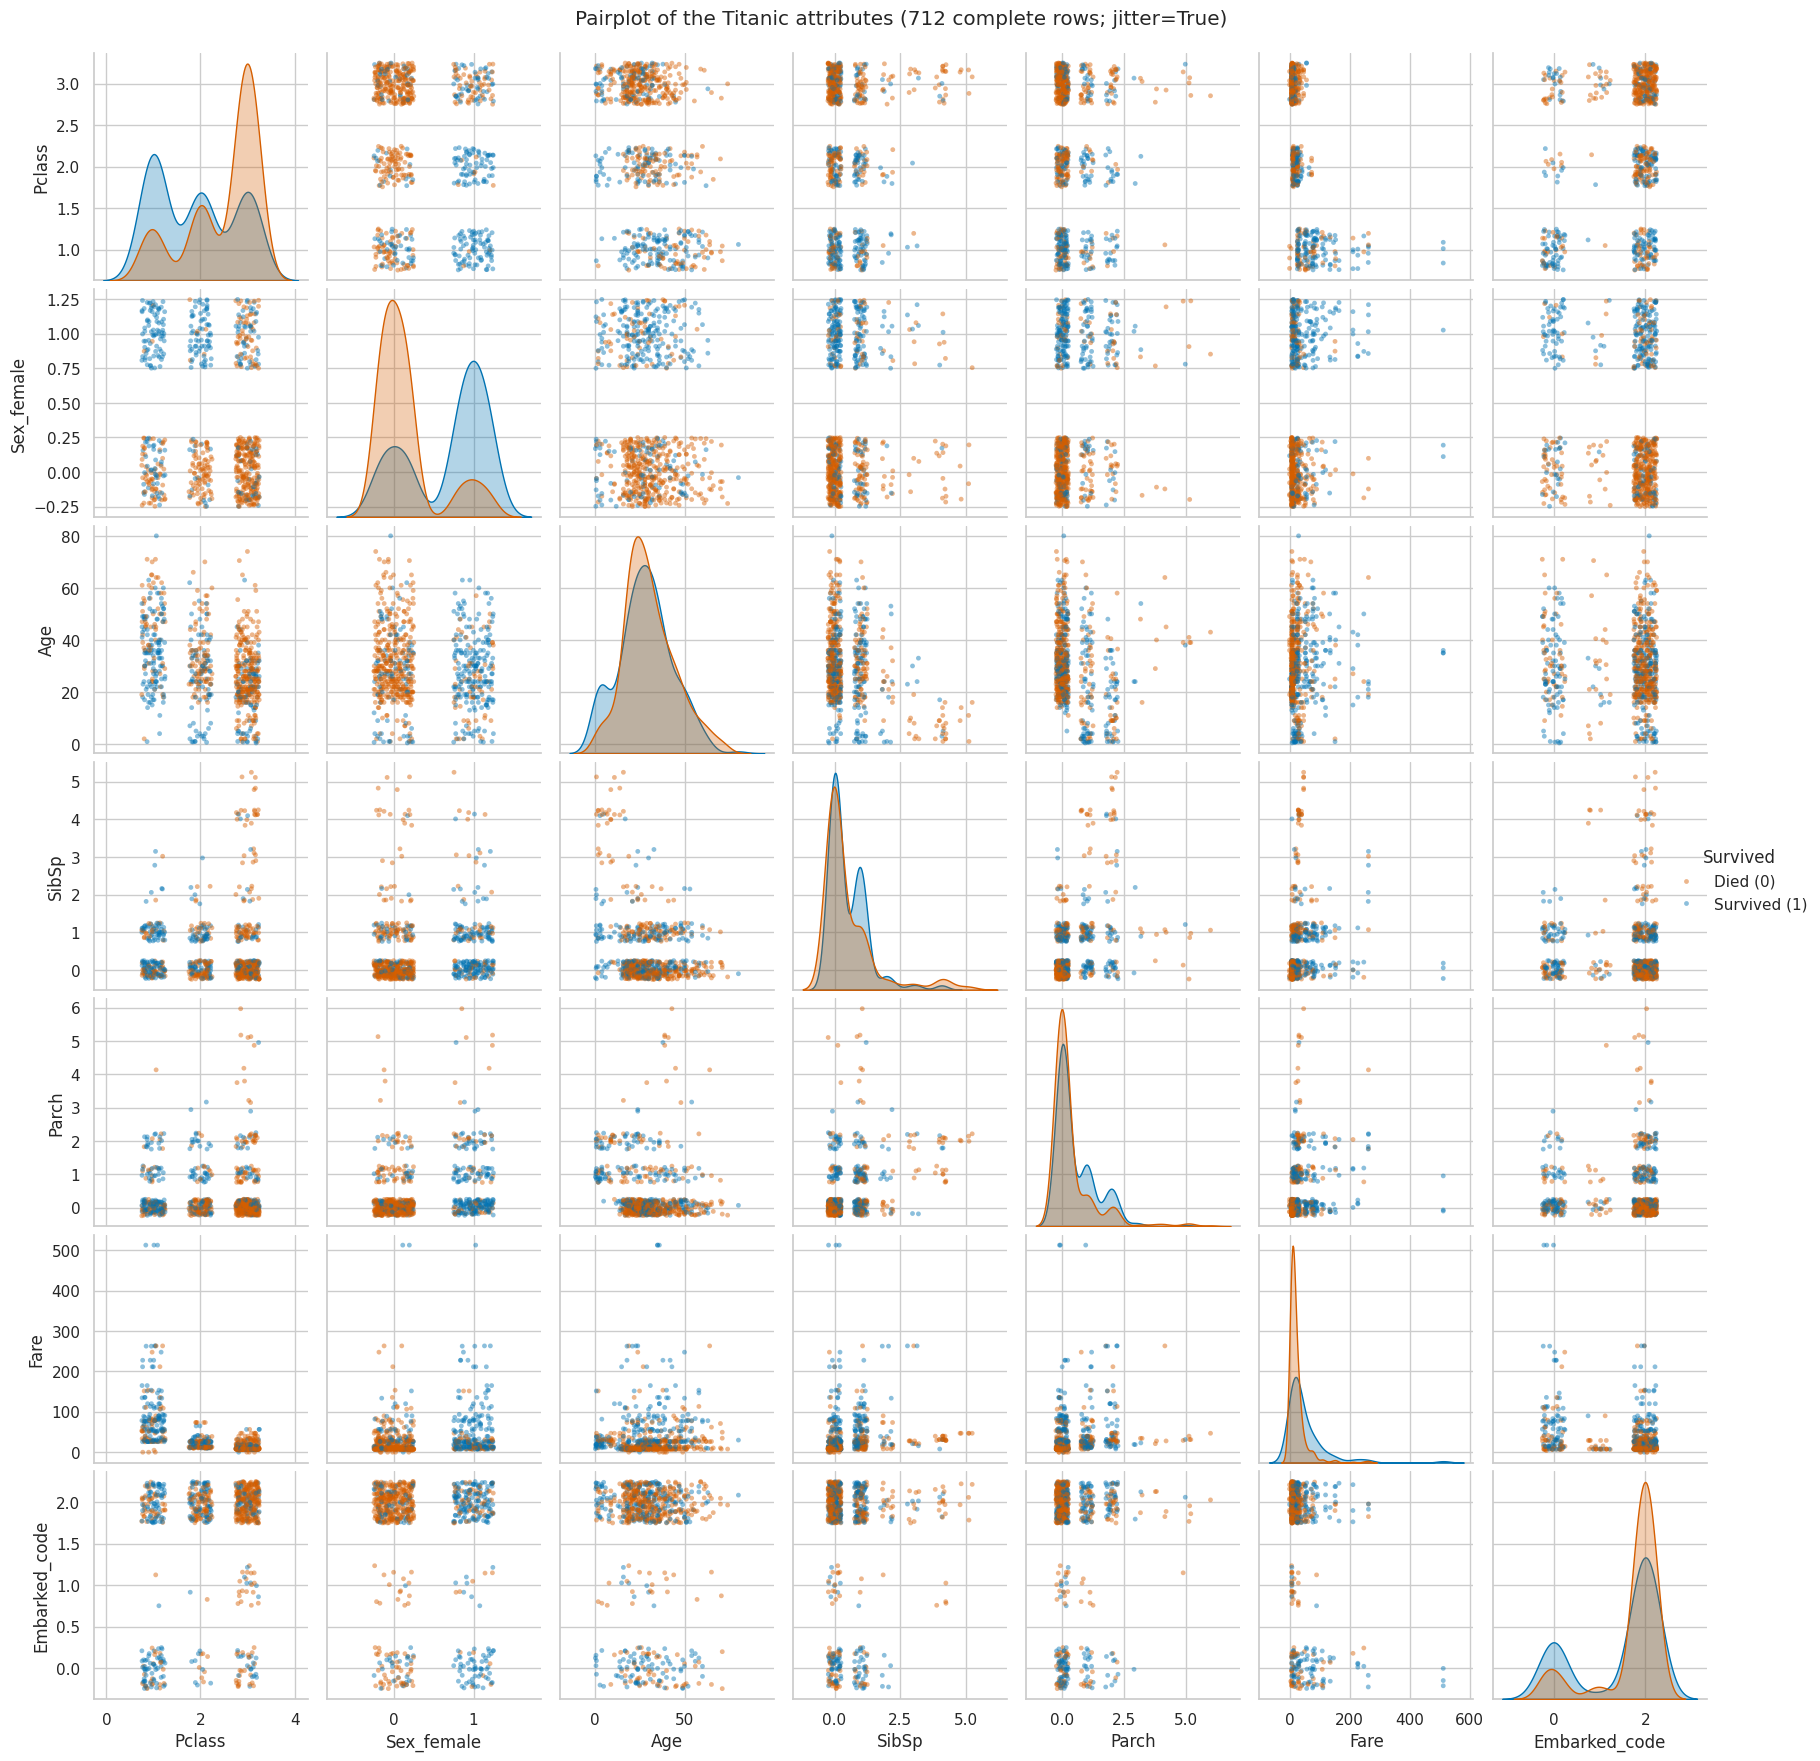

In [55]:
JITTER = True
discrete = ["Pclass", "Sex_female", "SibSp", "Parch", "Embarked_code"]

pp = X.dropna().copy()          # rows with missing Age/Embarked are not plotted
if JITTER:
    rng = np.random.default_rng(RANDOM_STATE)
    for c in discrete:
        pp[c] = pp[c] + rng.uniform(-0.25, 0.25, size=len(pp))
pp["Fare"] = pp["Fare"]          # try np.log1p(pp["Fare"]) to "open up" the Fare axis

g = sns.pairplot(pp, vars=features, hue=CLASS, palette=PALETTE, corner=False, diag_kind="kde",
                 plot_kws=dict(s=12, alpha=.45, edgecolor="none"),
                 diag_kws=dict(common_norm=False, fill=True, alpha=.3))
g._legend.set_title("Survived")
for t, l in zip(g._legend.texts, [CLASS_LABELS[0], CLASS_LABELS[1]]):
    t.set_text(l)
g.fig.suptitle(f"Pairplot of the Titanic attributes ({len(pp)} complete rows; jitter={JITTER})", y=1.01)
plt.show()

## 3.3 Visual inspection by attribute type

As in the slides, the best chart depends on the types of the two attributes involved.

### Continuous vs continuous: scatter plot and heatmap
With ~700 points a scatter plot is still readable; a 2D-histogram **heatmap** aggregates points and shows where the mass of data is.

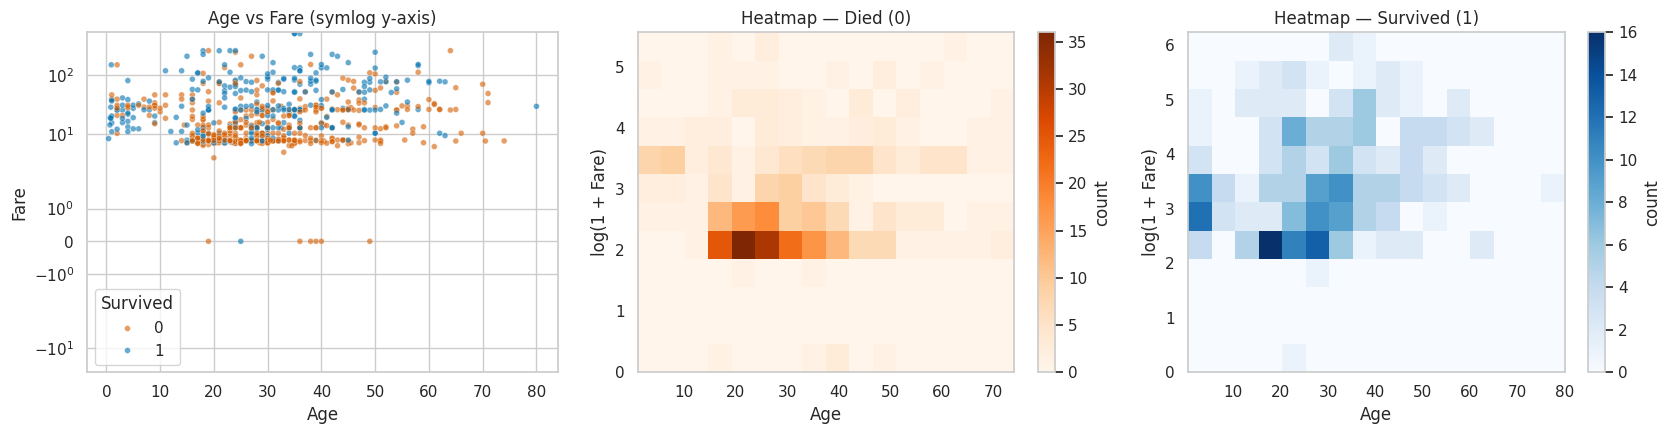

In [56]:
d = df[["Age", "Fare", CLASS]].dropna()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=d, x="Age", y="Fare", hue=CLASS, palette=PALETTE, s=18, alpha=.6, ax=axes[0])
axes[0].set_yscale("symlog"); axes[0].set_title("Age vs Fare (symlog y-axis)")
for ax, k in zip(axes[1:], [0, 1]):
    sub = d[d[CLASS] == k]
    h = ax.hist2d(sub["Age"], np.log1p(sub["Fare"]), bins=[16, 12], cmap="Oranges" if k == 0 else "Blues")
    fig.colorbar(h[3], ax=ax, label="count")
    ax.set_xlabel("Age"); ax.set_ylabel("log(1 + Fare)"); ax.set_title(f"Heatmap — {CLASS_LABELS[k]}")
plt.tight_layout(); plt.show()

### Categorical vs continuous: box plots and density plots

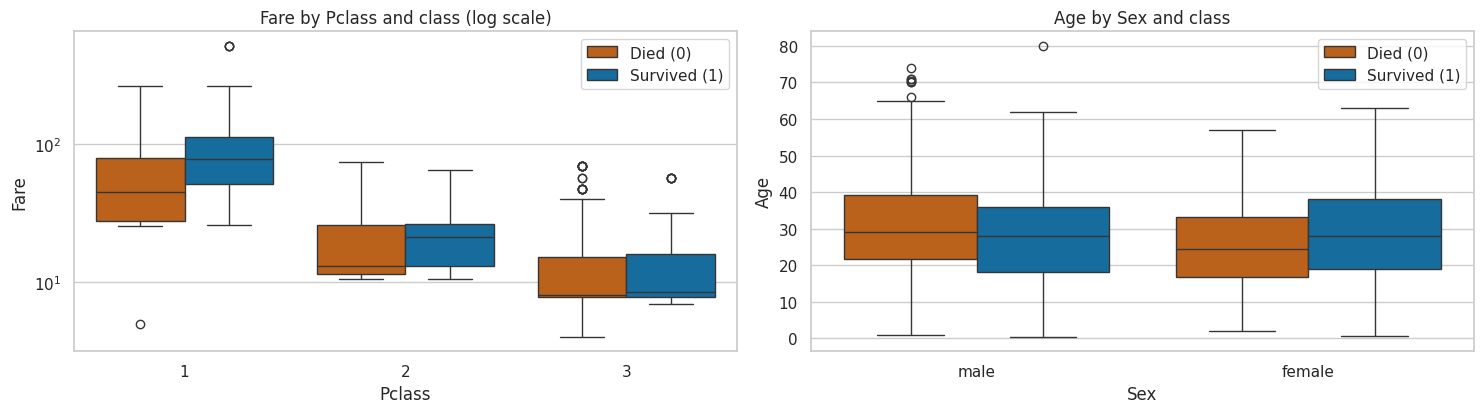

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
sns.boxplot(data=df, x="Pclass", y="Fare", hue=CLASS, palette=PALETTE, ax=axes[0], log_scale=True)
axes[0].set_title("Fare by Pclass and class (log scale)")
sns.boxplot(data=df, x="Sex", y="Age", hue=CLASS, palette=PALETTE, ax=axes[1])
axes[1].set_title("Age by Sex and class")
for ax in axes:
    h, _ = ax.get_legend_handles_labels(); ax.legend(h, [CLASS_LABELS[0], CLASS_LABELS[1]], title="")
plt.tight_layout(); plt.show()

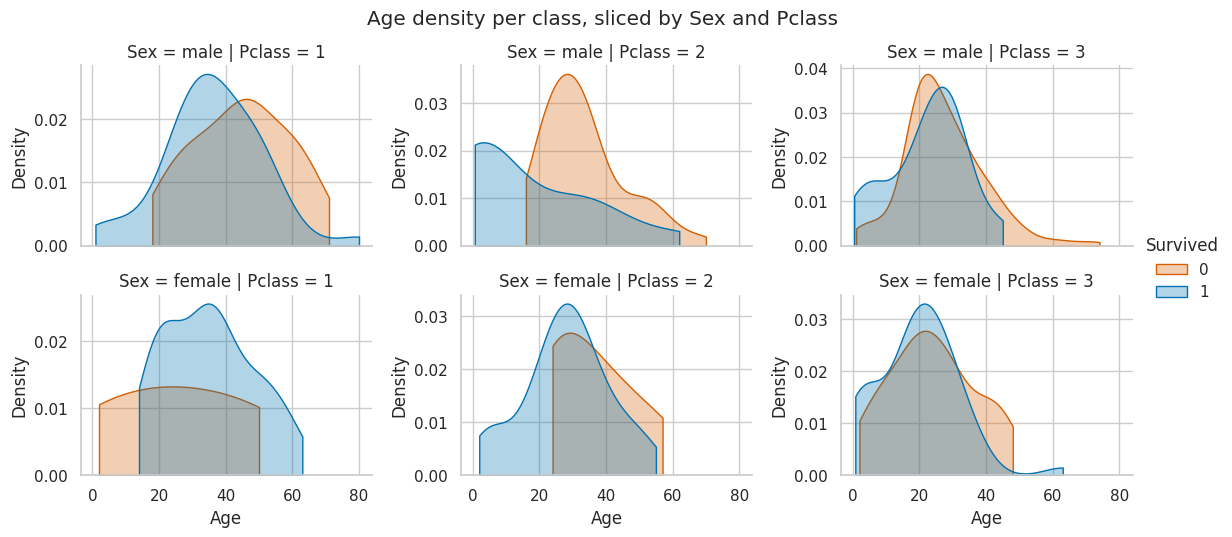

In [58]:
# Density of Age for every (Sex, Pclass) slice, coloured by class
g = sns.FacetGrid(df.dropna(subset=["Age"]), row="Sex", col="Pclass", hue=CLASS, palette=PALETTE,
                  height=2.6, aspect=1.5, sharey=False)
g.map_dataframe(sns.kdeplot, x="Age", fill=True, alpha=.3, common_norm=False, cut=0, warn_singular=False)
g.add_legend(title="Survived")
g.fig.suptitle("Age density per class, sliced by Sex and Pclass", y=1.03)
plt.show()

### Categorical vs categorical: stacked bar charts and heatmap of the survival rate

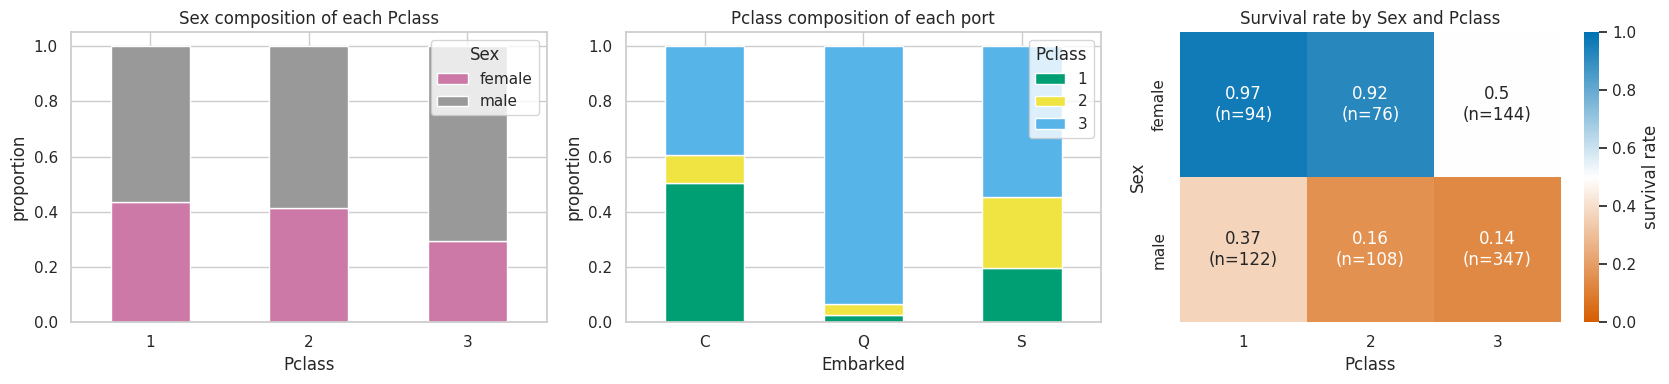

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
# 1) composition of each class by sex (proportions)
pd.crosstab(df["Pclass"], df["Sex"], normalize="index").plot(kind="bar", stacked=True, ax=axes[0], rot=0,
                                                              color=["#CC79A7", "#999999"])
axes[0].set_title("Sex composition of each Pclass"); axes[0].set_ylabel("proportion")
# 2) composition of each port by Pclass
pd.crosstab(df["Embarked"], df["Pclass"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1], rot=0,
                                                                   color=["#009E73", "#F0E442", "#56B4E9"])
axes[1].set_title("Pclass composition of each port"); axes[1].set_ylabel("proportion")
# 3) survival rate for each Sex x Pclass combination (with counts)
rate = df.pivot_table(index="Sex", columns="Pclass", values=CLASS, aggfunc="mean")
cnt = df.pivot_table(index="Sex", columns="Pclass", values=CLASS, aggfunc="size")
annot = rate.round(2).astype(str) + "\n(n=" + cnt.astype(str) + ")"
sns.heatmap(rate, annot=annot, fmt="", cmap=sns.blend_palette([PALETTE[0], "white", PALETTE[1]], as_cmap=True),
            vmin=0, vmax=1, ax=axes[2], cbar_kws={"label": "survival rate"})
axes[2].set_title("Survival rate by Sex and Pclass")
plt.tight_layout(); plt.show()

## 3.4 Dataset slicing

The profile of the data may differ across sub-populations. Let us compare the survival rate per port of embarkation **overall** and **within each ticket class**.

,overall,Pclass=1,Pclass=2,Pclass=3
Embarked,,,,
C,0.55,0.69,0.53,0.38
Q,0.39,0.50,0.67,0.38
S,0.34,0.58,0.46,0.19


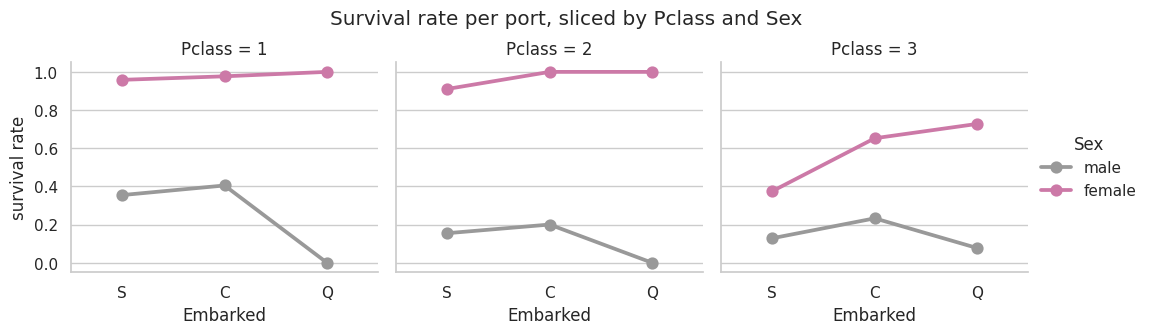

In [60]:
overall = df.groupby("Embarked")[CLASS].mean().rename("overall")
by_class = df.pivot_table(index="Embarked", columns="Pclass", values=CLASS, aggfunc="mean")
by_class.columns = [f"Pclass={c}" for c in by_class.columns]
display(pd.concat([overall, by_class], axis=1).round(2))

g = sns.catplot(data=df, x="Embarked", y=CLASS, col="Pclass", hue="Sex", kind="point",
                palette={"female": "#CC79A7", "male": "#999999"}, height=3.2, aspect=1.1, errorbar=None)
g.set_axis_labels("Embarked", "survival rate"); g.fig.suptitle("Survival rate per port, sliced by Pclass and Sex", y=1.04)
plt.show()

## 3.5 Pearson correlation

Pearson correlation measures the **linear** relationship between two attributes and ranges in [-1, 1]. We also show Spearman's rank correlation, which captures any *monotonic* relationship and is less sensitive to outliers and skewness.

 For a binary attribute (e.g. `Sex_female`, `Survived`) Pearson correlation is still well defined (point-biserial correlation). For the arbitrary code `Embarked_code` it is **not** meaningful: changing the coding changes the value.

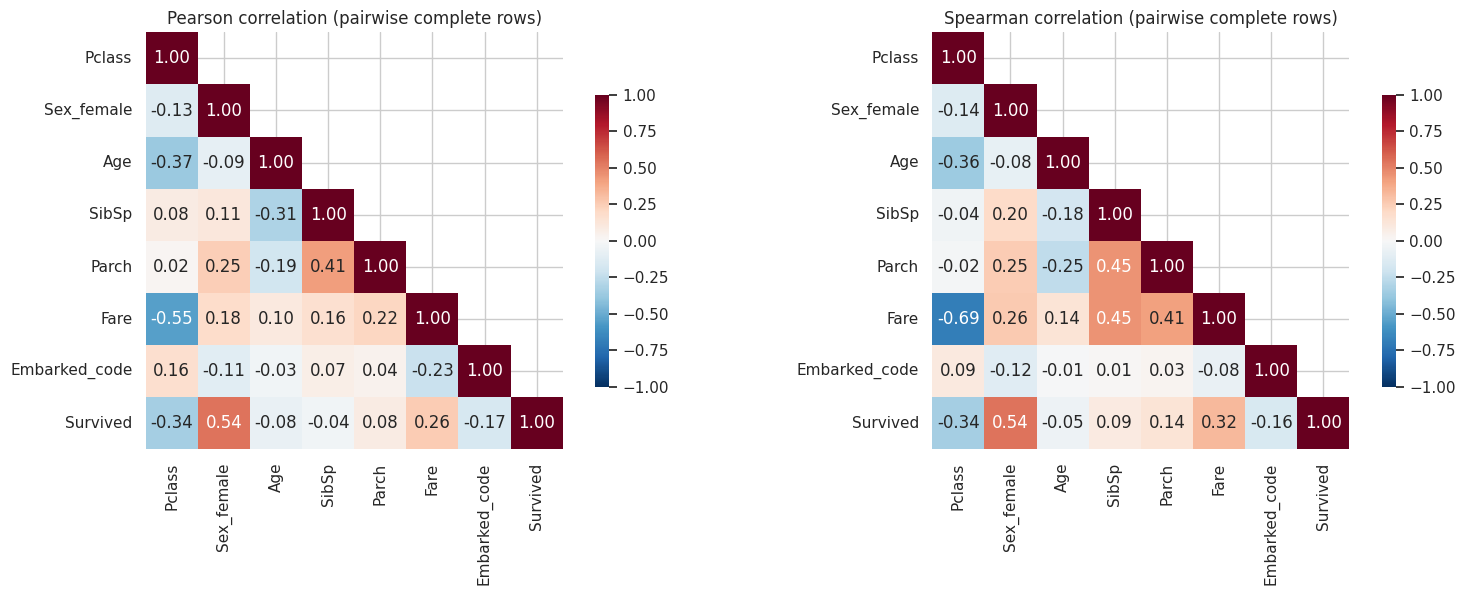

In [61]:
cols = features + [CLASS]
pearson = X[cols].corr(method="pearson")
spearman = X[cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, m) in zip(axes, [("Pearson", pearson), ("Spearman", spearman)]):
    sns.heatmap(m, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                mask=np.triu(np.ones_like(m, dtype=bool), k=1), cbar_kws={"shrink": .7})
    ax.set_title(f"{name} correlation (pairwise complete rows)")
plt.tight_layout(); plt.show()

## 3.6 Mutual Information

Mutual Information measures how much knowing one variable reduces the uncertainty on the other:

$$MI(X;Y)=\sum_{x,y} p(x,y)\,\log_2\frac{p(x,y)}{p(x)\,p(y)}$$

It is 0 if and only if the two variables are independent, and it captures **non-linear** dependencies too. It does **not** depend on how categories are coded, so it is meaningful also for `Embarked`.

To compute it on continuous attributes we discretise `Age` and `Fare` into 10 quantile bins. Since MI is not bounded, we also show the **normalised MI** (NMI ∈ [0, 1]).

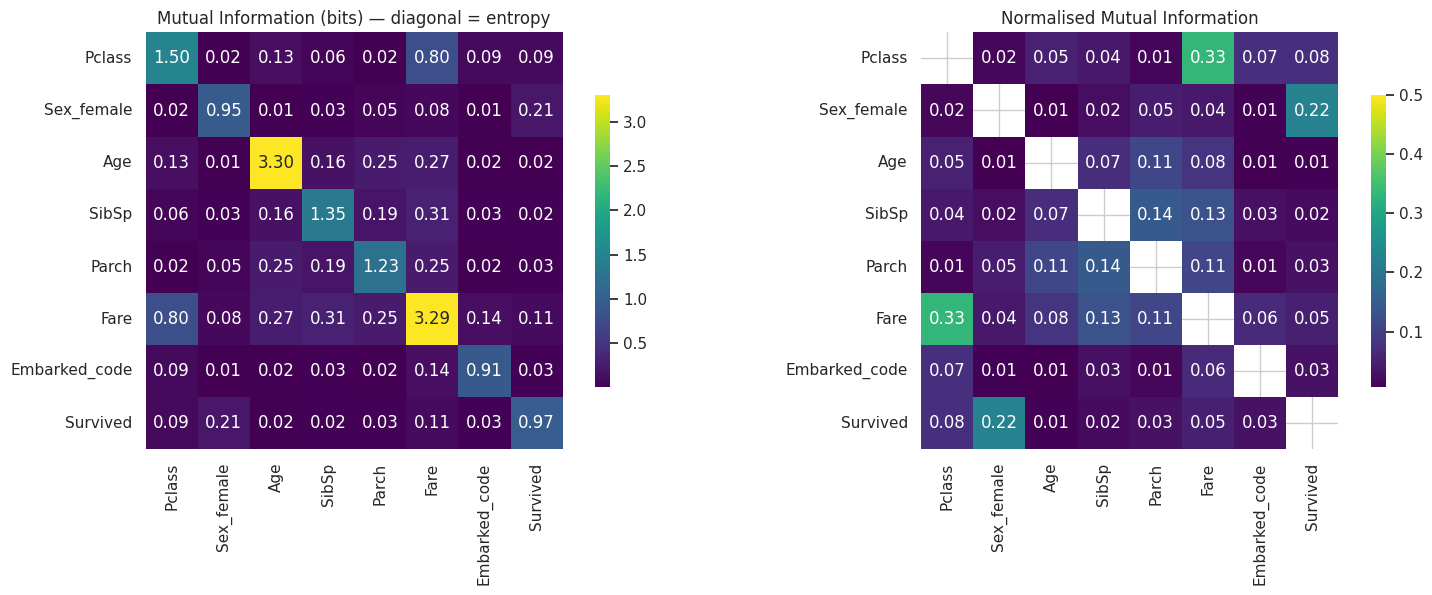

In [62]:
from sklearn.metrics import normalized_mutual_info_score

def discretise(s, bins=10):
    return pd.qcut(s, q=bins, duplicates="drop").cat.codes if s.nunique() > bins else s

D = X.dropna().copy()
for c in ["Age", "Fare"]:
    D[c] = discretise(D[c])

mi = pd.DataFrame(index=cols, columns=cols, dtype=float)
nmi = pd.DataFrame(index=cols, columns=cols, dtype=float)
for a in cols:
    for b in cols:
        mi.loc[a, b] = mutual_info_score(D[a], D[b]) / np.log(2)    # nats -> bits
        nmi.loc[a, b] = normalized_mutual_info_score(D[a], D[b])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(mi, annot=True, fmt=".2f", cmap="viridis", square=True, ax=axes[0], cbar_kws={"shrink": .7})
axes[0].set_title("Mutual Information (bits) — diagonal = entropy")
sns.heatmap(nmi, annot=True, fmt=".2f", cmap="viridis", square=True, ax=axes[1], vmax=.5,
            mask=np.eye(len(cols), dtype=bool), cbar_kws={"shrink": .7})
axes[1].set_title("Normalised Mutual Information")
plt.tight_layout(); plt.show()

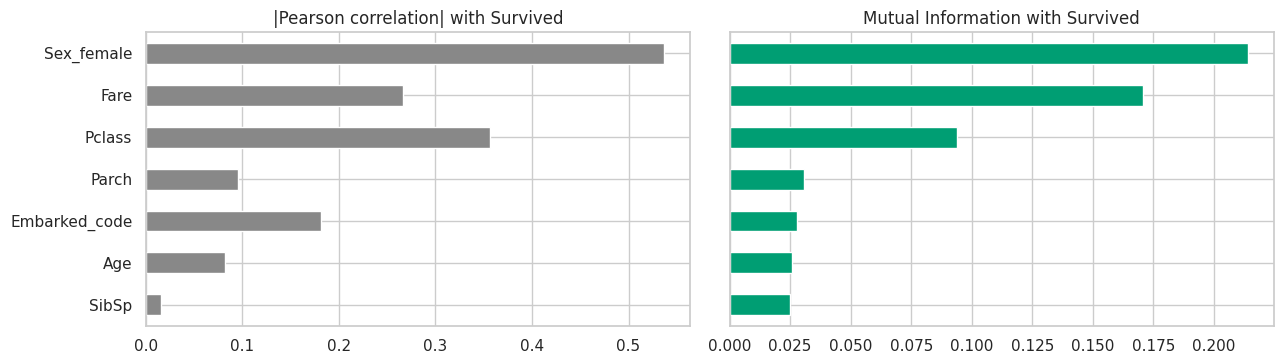

,|Pearson|,MI with class (bits)
SibSp,0.016,0.025
Age,0.082,0.026
Embarked_code,0.182,0.028
Parch,0.095,0.031
Pclass,0.356,0.094
Fare,0.266,0.171
Sex_female,0.537,0.214


In [63]:
# Relationship of every attribute with the class: |Pearson| vs Mutual Information
Xc = X.dropna()
mi_class = mutual_info_classif(Xc[features], Xc[CLASS], random_state=RANDOM_STATE,
                               discrete_features=[c in discrete for c in features]) / np.log(2)
rel = pd.DataFrame({"|Pearson|": Xc[features].corrwith(Xc[CLASS]).abs(),
                    "MI with class (bits)": mi_class}, index=features).sort_values("MI with class (bits)")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
rel["|Pearson|"].plot(kind="barh", ax=axes[0], color="#888888"); axes[0].set_title("|Pearson correlation| with Survived")
rel["MI with class (bits)"].plot(kind="barh", ax=axes[1], color="#009E73"); axes[1].set_title("Mutual Information with Survived")
plt.tight_layout(); plt.show()
rel.round(3)

### A non-linear relationship: Age vs Survived

Pearson correlation between `Age` and `Survived` is close to 0. Does this mean that age does not matter? Let us look at the survival rate per age band.

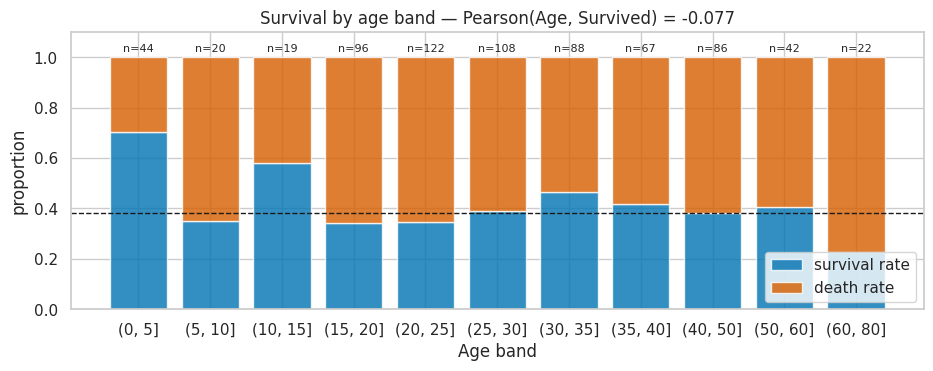

In [64]:
bands = pd.cut(df["Age"], bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80])
tab = df.groupby(bands, observed=True)[CLASS].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(tab.index.astype(str), tab["mean"], color=PALETTE[1], alpha=.8, label="survival rate")
ax.bar(tab.index.astype(str), 1 - tab["mean"], bottom=tab["mean"], color=PALETTE[0], alpha=.8, label="death rate")
ax.axhline(overall_rate, ls="--", color="k", lw=1)
for i, n in enumerate(tab["size"]):
    ax.text(i, 1.02, f"n={n}", ha="center", fontsize=8)
ax.set_ylim(0, 1.1); ax.set_xlabel("Age band"); ax.set_ylabel("proportion"); ax.legend(loc="lower right")
ax.set_title(f"Survival by age band — Pearson(Age, Survived) = {df['Age'].corr(df[CLASS]):.3f}")
plt.show()

###  Questions — patterns and relationships

**Pairplot and visual inspection**
1. In the pairplot, which **single** attribute (diagonal) separates the two colors best? Which **pair** of attributes (off-diagonal) gives the best separation between survivors and non-survivors?
2. Set `JITTER = False` and run the pairplot again. What happens to the scatter plots of discrete attributes? Why are scatter plots a poor choice for categorical attributes? Which chart would you use instead (see the slides)?
3. In the *Age vs Fare* scatter plot, is there any region of the plane where almost all points have the same color? Describe it in words (a "rule").
4. Look at the box plots *Fare by Pclass*: is the fare range of the three classes overlapping? Inside a class, do survivors tend to have paid more?
5. From the *Sex × Pclass* heatmap: how much does the survival rate of women drop from 2nd to 3rd class? And for men, from 1st to 2nd class? Is the effect of `Pclass` the same for both sexes? (*Interaction* between attributes.)
6. In the faceted density plots, for which slices is being young (age < 10) associated with a higher survival? Does the data support *"women **and children** first"*?

**Dataset slicing**

7. Passengers embarked in Cherbourg (C) have the highest overall survival rate. Is the port of embarkation a *cause* of survival? Use the *Pclass composition of each port* chart and the sliced survival rates to explain this result. What is the name of this phenomenon (a third variable that explains the relationship between two others)?

**Correlation and Mutual Information**

8. Which pair of attributes has the strongest (absolute) Pearson correlation? Explain it with your domain knowledge. Is the sign as you expected?
9. Why are Pearson and Spearman correlations between `Pclass` and `Fare` different? Which of the two is more appropriate given the skewness of `Fare` found in Part 2?
10. `SibSp` and `Parch` are positively correlated. What does this suggest about who travelled with whom? Could you combine them into a single, more meaningful attribute?
11. Compute (mentally) what would happen to the correlation between `Embarked_code` and `Fare` if we coded S = 0, C = 1, Q = 2. Does Mutual Information change with the coding? Why?
12. Compare the ranking of the attributes w.r.t. the class according to |Pearson| and according to MI. Where do they disagree the most? Use the *Age band* chart to explain why Pearson correlation of `Age` is nearly zero while age is clearly relevant for survival (remember the *x = y²* example in the slides).
13. Mutual Information was computed after **discretising** `Age` and `Fare` into 10 bins. How might the number of bins affect the result? (Optional: try 5 and 20 bins.)
14. List the 3 attributes that you expect to be the most useful for a classifier and the 2 that seem the least useful. Which hypotheses would you bring back to a *domain expert* (historian) for confirmation?

> ✍️ **Your answers:**
>
> ...

---
# Part 4 — Multivariate analysis: explaining the data in a 2D latent space

We cannot visualise the multi-dimensional space of our attributes (9 dimensions after one-hot encoding of `Embarked`) directly. We project it onto **two latent dimensions** with:
* **PCA** — linear, maximises global variance, axes are linear combinations of the original attributes (they can be *interpreted* through their loadings);
* **t-SNE** — non-linear, preserves local neighbourhoods; global distances and axes have no meaning.

**Important choices** (each is worth a question!):
* the class `Survived` is **not** used to compute the projection: it is only used to color the points. In this way we can check whether the *unsupervised* structure of the data is related to the class;
* `Embarked` is nominal, so we use **one-hot encoding** (one binary attribute per port) instead of the arbitrary code used in Part 3;
* rows with missing `Age` / `Embarked` are dropped (no imputation at this stage);
* as in the *Eating in the UK* example, we compare the results **with and without scaling**.

In [65]:
M = df.dropna(subset=["Age", "Embarked"]).copy()
Z = pd.DataFrame({
    "Pclass": M["Pclass"],
    "Sex_female": (M["Sex"] == "female").astype(int),
    "Age": M["Age"],
    "SibSp": M["SibSp"],
    "Parch": M["Parch"],
    "Fare": M["Fare"],
    "Emb_C": (M["Embarked"] == "C").astype(int),
    "Emb_Q": (M["Embarked"] == "Q").astype(int),
    "Emb_S": (M["Embarked"] == "S").astype(int),
}, index=M.index)
y = M[CLASS].values
print(f"{len(Z)} rows used ({len(df) - len(Z)} dropped because of missing values), {Z.shape[1]} attributes")
Z.describe().T[["mean", "std", "min", "max"]].round(2)

712 rows used (179 dropped because of missing values), 9 attributes


,mean,std,min,max
Pclass,2.24,0.84,1.00,3.00
Sex_female,0.36,0.48,0.00,1.00
Age,29.64,14.49,0.42,80.00
SibSp,0.51,0.93,0.00,5.00
Parch,0.43,0.85,0.00,6.00
Fare,34.57,52.94,0.00,512.33
Emb_C,0.18,0.39,0.00,1.00
Emb_Q,0.04,0.19,0.00,1.00
Emb_S,0.78,0.42,0.00,1.00


## 4.1 PCA: unscaled vs scaled data

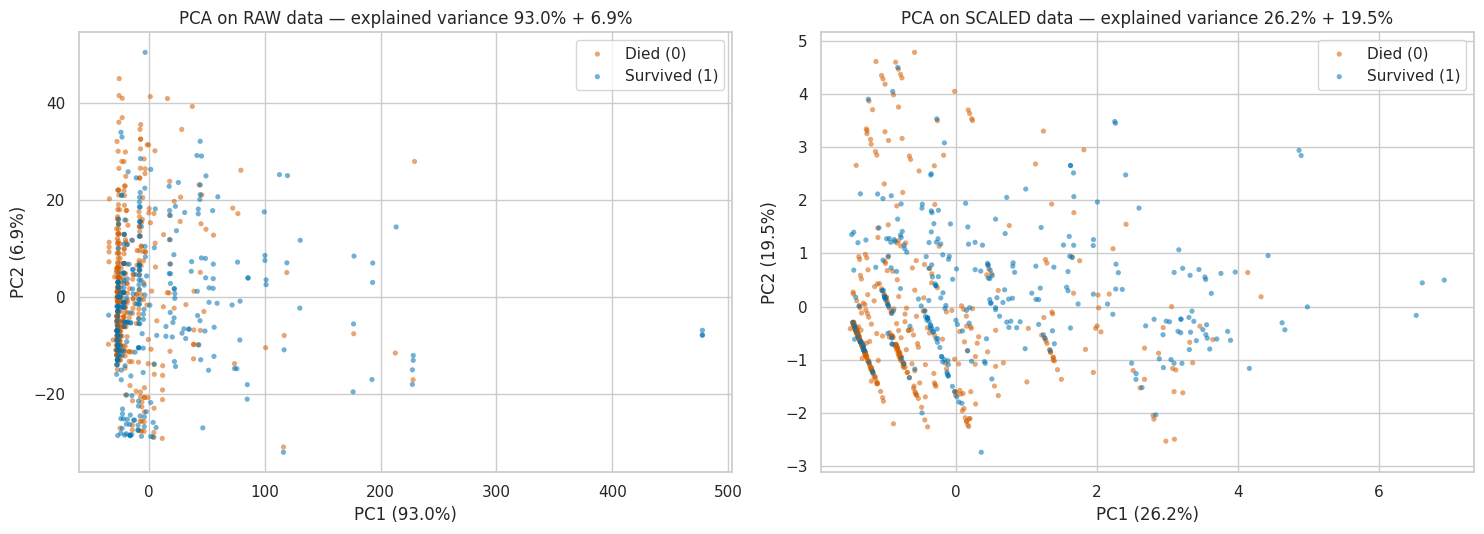

Loadings of PCA on raw data (rows = components):


,Pclass,Sex_female,Age,SibSp,Parch,Fare,Emb_C,Emb_Q,Emb_S
PC1,-0.009,0.002,0.028,0.002,0.003,1.000,0.002,-0.0,-0.002
PC2,-0.018,-0.004,0.999,-0.021,-0.012,-0.028,0.000,-0.0,-0.000


In [66]:
def scatter_by_class(ax, P, title, xlabel="PC1", ylabel="PC2"):
    for k in [0, 1]:
        ax.scatter(P[y == k, 0], P[y == k, 1], s=14, alpha=.55, c=PALETTE[k], label=CLASS_LABELS[k], edgecolors="none")
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.legend()

pca_raw = PCA(n_components=2).fit(Z)
P_raw = pca_raw.transform(Z)
Zs = StandardScaler().fit_transform(Z)
pca = PCA().fit(Zs)                    # keep all components to study the explained variance
P = pca.transform(Zs)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ev = pca_raw.explained_variance_ratio_
scatter_by_class(axes[0], P_raw, f"PCA on RAW data — explained variance {ev[0]:.1%} + {ev[1]:.1%}",
                 f"PC1 ({ev[0]:.1%})", f"PC2 ({ev[1]:.1%})")
ev = pca.explained_variance_ratio_
scatter_by_class(axes[1], P, f"PCA on SCALED data — explained variance {ev[0]:.1%} + {ev[1]:.1%}",
                 f"PC1 ({ev[0]:.1%})", f"PC2 ({ev[1]:.1%})")
plt.tight_layout(); plt.show()

print("Loadings of PCA on raw data (rows = components):")
display(pd.DataFrame(pca_raw.components_, columns=Z.columns, index=["PC1", "PC2"]).round(3))

### How much information do two components keep? (scree plot)

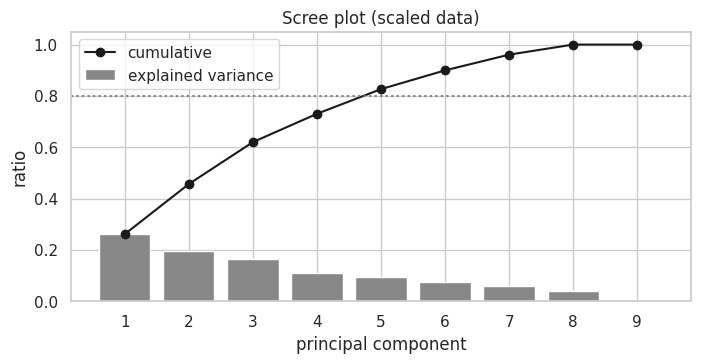

Cumulative explained variance: [0.262 0.457 0.62  0.73  0.826 0.9   0.961 1.    1.   ]


In [67]:
ev = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(1, len(ev) + 1), ev, color="#888888", label="explained variance")
ax.plot(range(1, len(ev) + 1), np.cumsum(ev), "o-", color="k", label="cumulative")
ax.axhline(0.8, ls=":", color="grey")
ax.set_xlabel("principal component"); ax.set_ylabel("ratio"); ax.set_xticks(range(1, len(ev) + 1)); ax.legend()
ax.set_title("Scree plot (scaled data)")
plt.show()
print("Cumulative explained variance:", np.round(np.cumsum(ev), 3))

### Interpreting the latent axes: loadings and biplot

Latent axes do not have a predefined meaning: we must **evaluate** them looking at the weight (*loading*) of each original attribute.

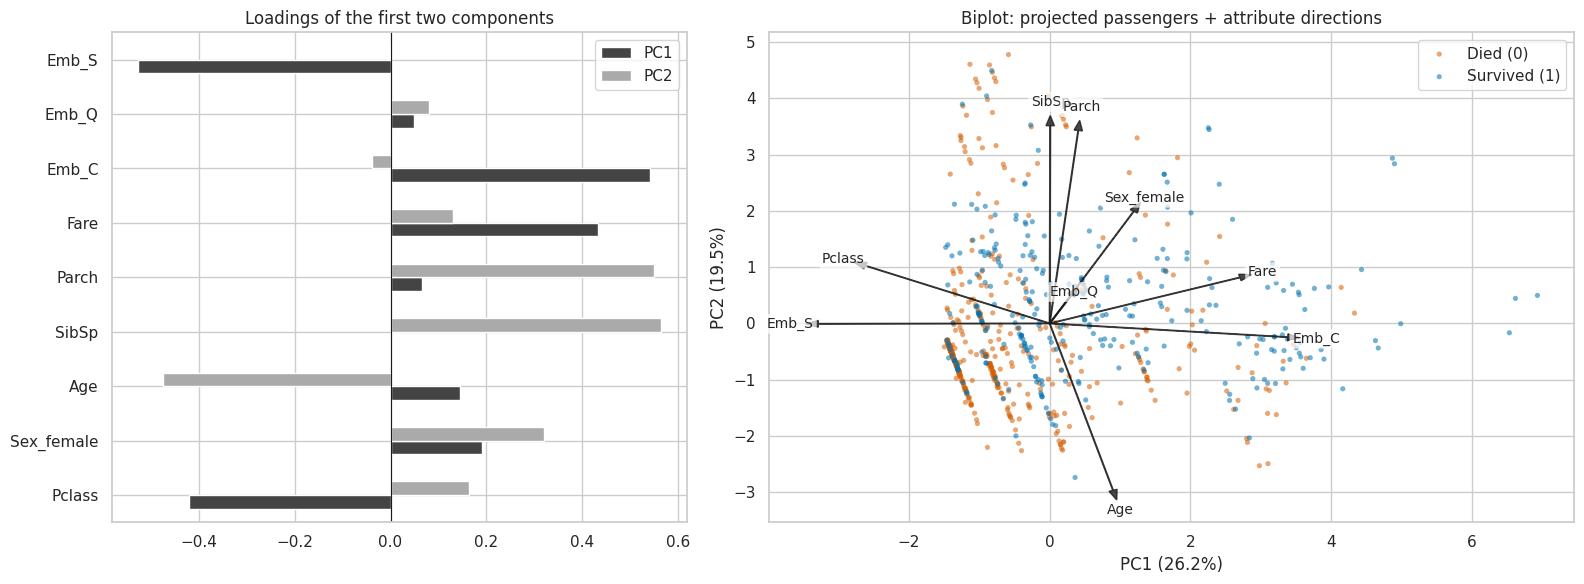

,PC1,PC2
Pclass,-0.420,0.165
Sex_female,0.192,0.320
Age,0.144,-0.475
SibSp,0.001,0.563
Parch,0.065,0.550
Fare,0.433,0.131
Emb_C,0.542,-0.039
Emb_Q,0.049,0.080
Emb_S,-0.527,-0.001


In [68]:
loadings = pd.DataFrame(pca.components_[:2].T, index=Z.columns, columns=["PC1", "PC2"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.4]})
loadings.plot(kind="barh", ax=axes[0], color=["#444444", "#AAAAAA"])
axes[0].axvline(0, color="k", lw=.8); axes[0].set_title("Loadings of the first two components")

scatter_by_class(axes[1], P[:, :2], "Biplot: projected passengers + attribute directions",
                 f"PC1 ({ev[0]:.1%})", f"PC2 ({ev[1]:.1%})")
scale = np.abs(P[:, :2]).max() * 0.9
for attr, (lx, ly) in loadings.iterrows():
    axes[1].arrow(0, 0, lx * scale, ly * scale, color="k", width=.01, head_width=.12, alpha=.8)
    axes[1].text(lx * scale * 1.12, ly * scale * 1.12, attr, fontsize=10, ha="center", va="center",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=.7, lw=0))
plt.tight_layout(); plt.show()
loadings.round(3)

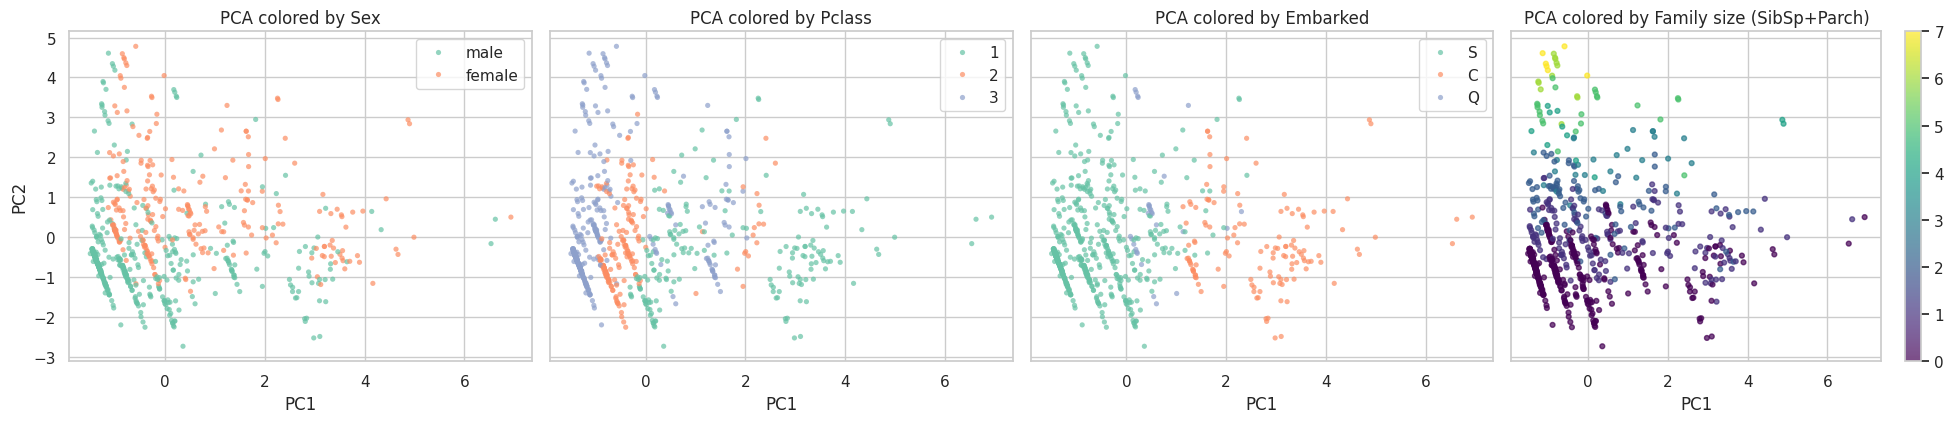

In [69]:
# The same PCA plane colored by other attributes: which attributes "explain" the structure of the cloud?
fig, axes = plt.subplots(1, 4, figsize=(20, 4.4), sharex=True, sharey=True)
for ax, (name, values, cmap) in zip(axes, [
        ("Sex", M["Sex"].values, None), ("Pclass", M["Pclass"].values, None),
        ("Embarked", M["Embarked"].values, None), ("Family size (SibSp+Parch)", (M["SibSp"] + M["Parch"]).values, "viridis")]):
    if cmap:
        sc = ax.scatter(P[:, 0], P[:, 1], c=values, cmap=cmap, s=12, alpha=.7); fig.colorbar(sc, ax=ax)
    else:
        sns.scatterplot(x=P[:, 0], y=P[:, 1], hue=values, s=14, alpha=.7, ax=ax, palette="Set2", edgecolor="none")
    ax.set_title(f"PCA colored by {name}"); ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.tight_layout(); plt.show()

## 4.2 t-SNE

t-SNE builds a 2D map in which passengers who are *similar* in the 9-dimensional (scaled) space are close to each other. The result depends on the **perplexity** (≈ number of neighbours each point "cares about") and on the random initialisation.

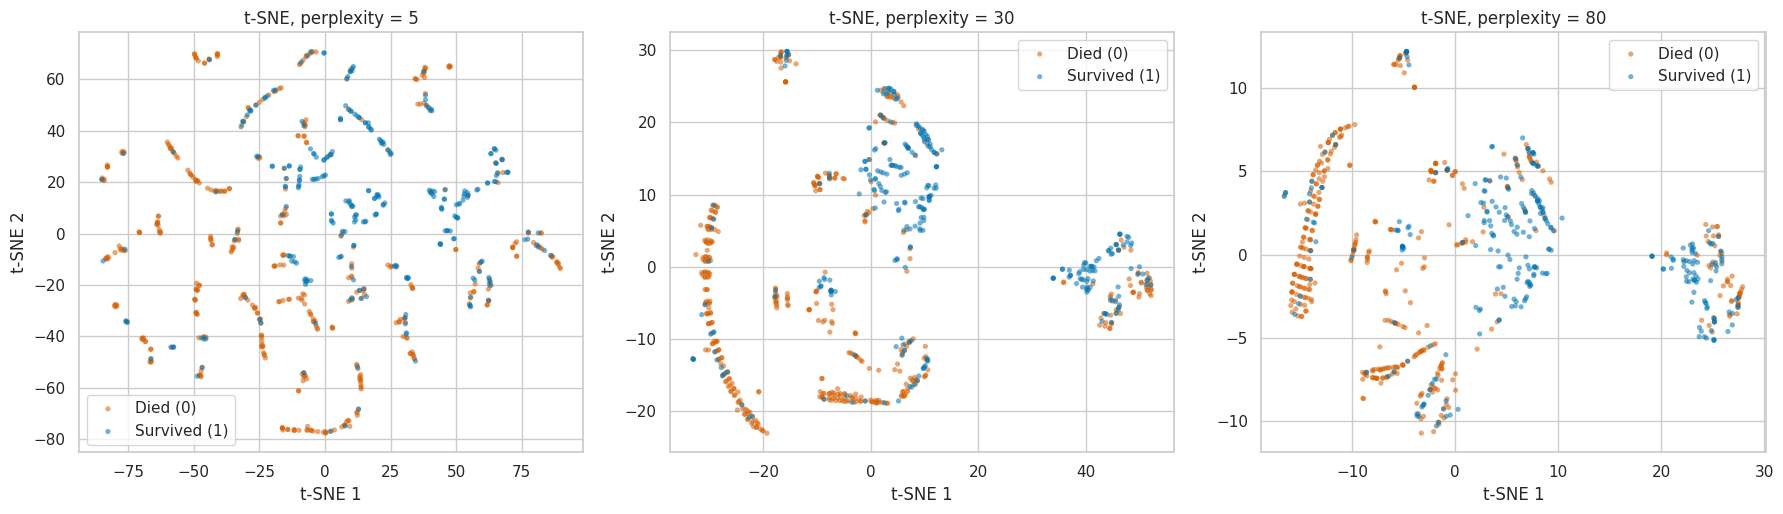

In [70]:
perplexities = [5, 30, 80]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 5.3))
tsne_maps = {}
for ax, perp in zip(axes, perplexities):
    T = TSNE(n_components=2, perplexity=perp, init="pca", random_state=RANDOM_STATE).fit_transform(Zs)
    tsne_maps[perp] = T
    scatter_by_class(ax, T, f"t-SNE, perplexity = {perp}", "t-SNE 1", "t-SNE 2")
plt.tight_layout(); plt.show()

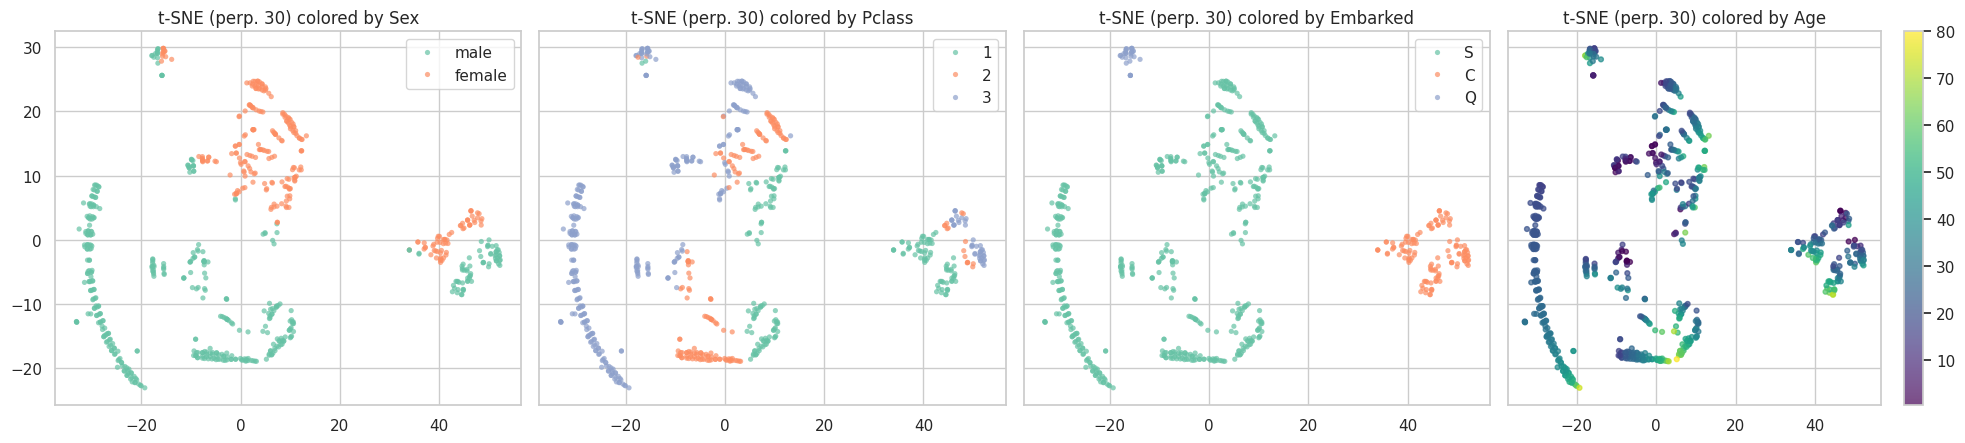

In [71]:
# Explaining the t-SNE clusters: color the same map (perplexity 30) by the original attributes
T = tsne_maps[30]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6), sharex=True, sharey=True)
for ax, (name, values, cmap) in zip(axes, [
        ("Sex", M["Sex"].values, None), ("Pclass", M["Pclass"].values, None),
        ("Embarked", M["Embarked"].values, None), ("Age", M["Age"].values, "viridis")]):
    if cmap:
        sc = ax.scatter(T[:, 0], T[:, 1], c=values, cmap=cmap, s=12, alpha=.7); fig.colorbar(sc, ax=ax)
    else:
        sns.scatterplot(x=T[:, 0], y=T[:, 1], hue=values, s=14, alpha=.7, ax=ax, palette="Set2", edgecolor="none")
    ax.set_title(f"t-SNE (perp. 30) colored by {name}")
plt.tight_layout(); plt.show()

In [72]:
# Survival rate inside each "natural" group found by t-SNE (Sex x Pclass x Embarked)
grp = M.groupby(["Sex", "Pclass", "Embarked"])[CLASS].agg(survival_rate="mean", n="size").round(2)
grp.sort_values("survival_rate", ascending=False)

survival_rate    n
Sex    Pclass Embarked                    
female 1      Q                  1.00    1
       2      C                  1.00    7
              Q                  1.00    1
       1      C                  0.97   38
              S                  0.95   44
       2      S                  0.91   66
       3      C                  0.69   16
              Q                  0.50   10
male   1      C                  0.44   36
female 3      S                  0.41   76
male   1      S                  0.38   64
       3      C                  0.28   25
       2      S                  0.16   90
       3      S                  0.14  214
       2      C                  0.12    8
       3      Q                  0.07   14
       2      Q                  0.00    1
       1      Q                  0.00    1

###  Questions — 2D latent space

**PCA**
1. Compare PCA on raw and on scaled data. On the raw data, which attribute dominates PC1 (look at the loadings)? Why? Relate your answer to the *Eating in the UK* example in the slides.
2. How much of the total variance is explained by the first two components of the scaled PCA? How many components are needed to reach 80%? Is a 2D view a faithful summary of this dataset?
3. Interpret the two latent axes using the loadings and the biplot: give each axis a *name* (e.g. "wealth", "family size", …). Which attributes point in the same direction and which in opposite directions? Is this consistent with the correlation matrix of Part 3?
4. Survival was **not** used to compute the PCA. Nevertheless, are survivors and non-survivors located in different regions of the plane? Along which direction do survivors concentrate? Which attribute arrow points towards them?
5. Looking at the PCA plots colored by Sex, Pclass and Embarked: which attributes explain the main "stripes" or groups of points? Remember the slides: *when does PCA fail?* Is our data well described by a single hyper-ellipsoid?

**t-SNE**

6. How does the t-SNE map change when the perplexity goes from 5 to 80? Which value gives the most readable picture?
7. t-SNE produces well-separated clusters. Using the colored maps, which attributes define the clusters? Why do discrete/binary attributes (after scaling) generate such neat islands?
8. Using the table of survival rates per (Sex, Pclass, Embarked), check that clusters with a predominance of blue points correspond to groups with a high survival rate. Which group has the highest and which the lowest survival rate?
9. Can you say that two clusters that are far apart in the t-SNE map are "more different" than two clusters that are close? Can you give a meaning to the t-SNE axes? Why not?
10. A new passenger arrives: can you place them on the existing PCA map? And on the t-SNE map?

**Data-centric reflection**

11. We dropped the passengers with missing `Age` before PCA/t-SNE. Which passengers are more often missing `Age` (check survival rate and Pclass of rows with missing Age)? Could dropping them **bias** the picture?
12. We used `Fare` as it is, although it is heavily skewed and refers to a *ticket*, not a passenger (Part 2). How could these issues affect the PCA? (Optional: replace `Fare` with `np.log1p(Fare)` and run the PCA again.)
13. Summing up Parts 2–4: write **3 hypotheses** on "which kinds of people were more likely to survive", each supported by a chart or a number of this notebook, and **3 data-quality issues** that must be addressed in the *Data Preparation* step.

>  **Your answers:**
>
> ...